# Phase 3 — Fine-Tuning ChemBERTa for Lipophilicity Prediction

In Phases 1 & 2 we used hand-crafted molecular features (fingerprints, descriptors).
Now we let a **pretrained language model** learn representations directly from SMILES strings.

**ChemBERTa** is a RoBERTa model pretrained on ~10 million SMILES strings from PubChem/ZINC.
It already "understands" molecular syntax — we just need to teach it what lipophilicity means
by fine-tuning on our labeled dataset.

This notebook covers:
1. Loading the pretrained ChemBERTa model from HuggingFace
2. Tokenizing SMILES strings
3. Setting up a regression head and fine-tuning
4. Comparing results against our Phase 1 & 2 baselines
5. Visualizing what the model attends to in a molecule

In [374]:
# If you haven't installed these yet:
# pip install torch transformers datasets PyTDC

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from tdc.single_pred import ADME

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 1. Load Data

Same scaffold split as Phases 1 & 2 for a fair comparison.

In [375]:
data = ADME(name='Lipophilicity_AstraZeneca', path='../data/')
split = data.get_split(method='scaffold', seed=SEED)

train_df = split['train'].reset_index(drop=True)
valid_df = split['valid'].reset_index(drop=True)
test_df  = split['test'].reset_index(drop=True)

print(f'Train: {len(train_df)}, Valid: {len(valid_df)}, Test: {len(test_df)}')
print(f'Target range: [{train_df["Y"].min():.2f}, {train_df["Y"].max():.2f}]')

Found local copy...
Loading...
Done!
100%|██████████| 4200/4200 [00:00<00:00, 5794.07it/s]

Train: 2940, Valid: 420, Test: 840
Target range: [-1.50, 4.50]


### 1.5 Augment the SMILES data

In [376]:
from rdkit import Chem

def randomize_smiles(smiles, n=5):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [smiles]
    variants = set()
    for _ in range(n * 3):  # generate extras since some may be duplicates
        variants.add(Chem.MolToSmiles(mol, doRandom=True))
        if len(variants) >= n:
            break
    return list(variants)

# Augment training set only (never augment valid/test)
aug_smiles = []
aug_targets = []

for smi, y in zip(train_df['Drug'], train_df['Y']):
    variants = randomize_smiles(smi, n=5)
    aug_smiles.extend(variants)
    aug_targets.extend([y] * len(variants))

print(f'Training set: {len(train_df)} → {len(aug_smiles)} molecules')

# Replace train_df with augmented version
train_df = pd.DataFrame({'Drug': aug_smiles, 'Y': aug_targets})

# Scale the targets
y_scaler = StandardScaler()
train_df['Y_scaled'] = y_scaler.fit_transform(train_df['Y'].values.reshape(-1, 1)).flatten()
valid_df['Y_scaled'] = y_scaler.transform(valid_df['Y'].values.reshape(-1, 1)).flatten()
test_df['Y_scaled']  = y_scaler.transform(test_df['Y'].values.reshape(-1, 1)).flatten()

Training set: 2940 → 14700 molecules


## 2. Load ChemBERTa Tokenizer & Model

We use `seyonec/ChemBERTa-zinc-base-v1`, which was pretrained on SMILES from the
ZINC database using masked language modeling — the same pretraining objective as BERT/RoBERTa,
but on molecular strings instead of English text.

In [377]:
# MODEL_NAME = 'seyonec/ChemBERTa-zinc-base-v1'
MODEL_NAME = 'DeepChem/ChemBERTa-77M-MLM'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModel.from_pretrained(MODEL_NAME)

print(f'Model: {MODEL_NAME}')
print(f'Hidden size: {base_model.config.hidden_size}')
print(f'Vocab size: {tokenizer.vocab_size}')
print(f'Parameters: {sum(p.numel() for p in base_model.parameters()):,}')

Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: DeepChem/ChemBERTa-77M-MLM
Hidden size: 384
Vocab size: 591
Parameters: 3,427,440


In [378]:
# See how SMILES get tokenized
example_smiles = 'CC(=O)OC1=CC=CC=C1C(=O)O'  # Aspirin
tokens = tokenizer.tokenize(example_smiles)
token_ids = tokenizer.encode(example_smiles)

print(f'SMILES:   {example_smiles}')
print(f'Tokens:   {tokens}')
print(f'Token IDs: {token_ids}')
print(f'Num tokens: {len(tokens)}')

SMILES:   CC(=O)OC1=CC=CC=C1C(=O)O
Tokens:   ['C', 'C', '(', '=', 'O', ')', 'O', 'C', '1', '=', 'C', 'C', '=', 'C', 'C', '=', 'C', '1', 'C', '(', '=', 'O', ')', 'O']
Token IDs: [12, 16, 16, 17, 22, 19, 18, 19, 16, 20, 22, 16, 16, 22, 16, 16, 22, 16, 20, 16, 17, 22, 19, 18, 19, 13]
Num tokens: 24


## 3. Create a PyTorch Dataset

We need to tokenize SMILES strings and pair them with logD targets.

In [379]:
class SMILESDataset(Dataset):
    """Dataset that tokenizes SMILES on-the-fly."""

    def __init__(self, smiles_list, targets, tokenizer, max_length=128):
        self.smiles = smiles_list
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.smiles[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'target': torch.tensor(self.targets[idx], dtype=torch.float32),
        }


# Check SMILES lengths to pick a good max_length
token_lengths = [len(tokenizer.tokenize(s)) for s in train_df['Drug']]
print(f'Token length stats (train):')
print(f'  Mean: {np.mean(token_lengths):.1f}')
print(f'  Max:  {np.max(token_lengths)}')
print(f'  95th percentile: {np.percentile(token_lengths, 95):.0f}')

MAX_LENGTH = min(128, int(np.percentile(token_lengths, 99)) + 10)
print(f'\nUsing max_length = {MAX_LENGTH}')

Token length stats (train):
  Mean: 46.7
  Max:  209
  95th percentile: 68

Using max_length = 89


In [392]:
# Create datasets and dataloaders
BATCH_SIZE = 64
DROPOUT = 0.1

# train_dataset = SMILESDataset(train_df['Drug'].tolist(), train_df['Y'].values, tokenizer, MAX_LENGTH)
# valid_dataset = SMILESDataset(valid_df['Drug'].tolist(), valid_df['Y'].values, tokenizer, MAX_LENGTH)
# test_dataset  = SMILESDataset(test_df['Drug'].tolist(), test_df['Y'].values, tokenizer, MAX_LENGTH)

train_dataset = SMILESDataset(train_df['Drug'].tolist(), train_df['Y_scaled'].values, tokenizer, MAX_LENGTH)
valid_dataset = SMILESDataset(valid_df['Drug'].tolist(), valid_df['Y_scaled'].values, tokenizer, MAX_LENGTH)
test_dataset  = SMILESDataset(test_df['Drug'].tolist(), test_df['Y_scaled'].values, tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Batches — train: {len(train_loader)}, valid: {len(valid_loader)}, test: {len(test_loader)}')

Batches — train: 230, valid: 7, test: 14


## 4. Define the Regression Model

We take ChemBERTa's `[CLS]` token output (a learned summary of the full SMILES)
and pass it through a small regression head to predict logD.

In [ ]:
class ChemBERTaRegressor(nn.Module):
    """ChemBERTa with a regression head for property prediction."""

    def __init__(self, base_model, hidden_size, dropout=0.1):
        super().__init__()
        self.base_model = base_model
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 256),   # hidden_size → 256
            nn.ReLU(),                      # activation
            nn.Dropout(dropout),
            nn.Linear(256, 1),              # 256 → 1 prediction
        )
        # self.head = nn.Sequential(
        #     nn.Dropout(dropout),
        #     nn.Linear(hidden_size, 1),     # hidden_size → 1 prediction directly
        # )

    def forward(self, input_ids, attention_mask):
        outputs = self.base_model(input_ids=input_ids, attention_mask=attention_mask)
        hidden = outputs.last_hidden_state  # (batch, seq, hidden)
        
        # Mean pool over non-padding tokens
        mask = attention_mask.unsqueeze(-1).float()  # (batch, seq, 1)
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)
        
        return self.head(pooled).squeeze(-1)


hidden_size = base_model.config.hidden_size
model = ChemBERTaRegressor(base_model, hidden_size, dropout=DROPOUT).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Total parameters: 3,526,257
Trainable parameters: 3,526,257


### 4.5 Freeze Pretrained Model Layers

In [382]:
# Freeze all base model layers
for param in model.base_model.parameters():
    param.requires_grad = False

# # Unfreeze only the last 2 transformer layers
# for param in model.base_model.encoder.layer[-2:].parameters():
#     param.requires_grad = True

# Unfreeze only the first 2 transformer layers
for param in model.base_model.encoder.layer[2:].parameters():
    param.requires_grad = True

# Verify — should be much lower than before
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

Trainable: 1,048,913 / 3,526,257 (29.7%)


## 5. Training Setup

Key choices for fine-tuning a pretrained model:
- **Low learning rate** — we don't want to destroy what ChemBERTa already learned
- **Warmup** — gradually increase LR at the start to stabilize training
- **Early stopping** — stop when validation loss stops improving

In [383]:
# Hyperparameters
LEARNING_RATE = 9e-5 # 2e-5, 9e-5
EPOCHS = 60 # 20, 40
WARMUP_FRACTION = 0.1
PATIENCE = 15  # early stopping patience, 5, 8

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_FRACTION)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

loss_fn = nn.MSELoss()

print(f'Total steps: {total_steps}')
print(f'Warmup steps: {warmup_steps}')
print(f'Early stopping patience: {PATIENCE} epochs')

Total steps: 13800
Warmup steps: 1380
Early stopping patience: 15 epochs


## 6. Training Loop

In [384]:
def run_epoch(model, loader, loss_fn, optimizer=None, scheduler=None, train=True):
    """Run one epoch of training or evaluation."""
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0
    all_preds = []
    all_targets = []

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        targets = batch['target'].to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            preds = model(input_ids, attention_mask)
            loss = loss_fn(preds, targets)

        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            if scheduler:
                scheduler.step()

        total_loss += loss.item() * len(targets)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    r2 = r2_score(all_targets, all_preds)

    return avg_loss, rmse, r2, all_preds, all_targets

In [385]:
# Training
history = {'train_loss': [], 'valid_loss': [], 'train_r2': [], 'valid_r2': [],
           'train_rmse': [], 'valid_rmse': []}

best_valid_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f'{"Epoch":>5} | {"Train Loss":>10} | {"Valid Loss":>10} | '
      f'{"Train RMSE":>10} | {"Valid RMSE":>10} | {"Train R²":>8} | {"Valid R²":>8}')
print('-' * 85)

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss, train_rmse, train_r2, _, _ = run_epoch(
        model, train_loader, loss_fn, optimizer, scheduler, train=True
    )

    # Validate
    valid_loss, valid_rmse, valid_r2, _, _ = run_epoch(
        model, valid_loader, loss_fn, train=False
    )

    # Record history
    history['train_loss'].append(train_loss)
    history['valid_loss'].append(valid_loss)
    history['train_rmse'].append(train_rmse)
    history['valid_rmse'].append(valid_rmse)
    history['train_r2'].append(train_r2)
    history['valid_r2'].append(valid_r2)

    # Early stopping check
    marker = ''
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        patience_counter = 0
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        marker = ' ← best'
    else:
        patience_counter += 1

    print(f'{epoch:>5} | {train_loss:>10.4f} | {valid_loss:>10.4f} | '
          f'{train_rmse:>10.4f} | {valid_rmse:>10.4f} | {train_r2:>8.4f} | {valid_r2:>8.4f}{marker}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
        break

# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    model.to(device)
    print(f'\nRestored best model (valid loss = {best_valid_loss:.4f})')

Epoch | Train Loss | Valid Loss | Train RMSE | Valid RMSE | Train R² | Valid R²
-------------------------------------------------------------------------------------
    1 |     0.9897 |     0.9065 |     0.9949 |     0.9521 |   0.0103 |   0.0422 ← best
    2 |     0.9002 |     0.7267 |     0.9488 |     0.8525 |   0.0998 |   0.2322 ← best
    3 |     0.7286 |     0.5958 |     0.8536 |     0.7719 |   0.2714 |   0.3706 ← best
    4 |     0.6499 |     0.5613 |     0.8062 |     0.7492 |   0.3501 |   0.4070 ← best
    5 |     0.5936 |     0.5101 |     0.7705 |     0.7142 |   0.4064 |   0.4611 ← best
    6 |     0.5417 |     0.5110 |     0.7360 |     0.7148 |   0.4583 |   0.4601
    7 |     0.5054 |     0.4913 |     0.7109 |     0.7010 |   0.4946 |   0.4809 ← best
    8 |     0.4697 |     0.4761 |     0.6853 |     0.6900 |   0.5303 |   0.4970 ← best
    9 |     0.4458 |     0.4701 |     0.6676 |     0.6857 |   0.5542 |   0.5033 ← best
   10 |     0.4246 |     0.4750 |     0.6516 |     0.6892 

## 7. Training Curves

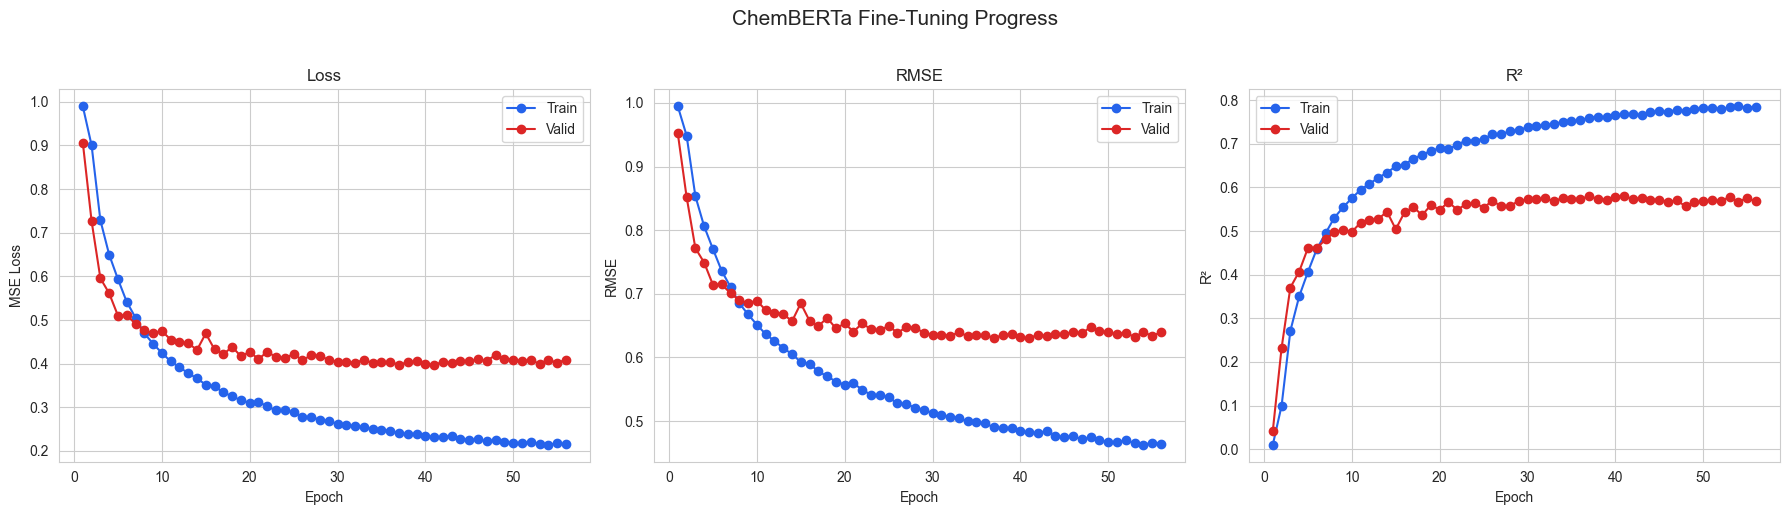

In [387]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train', color='#2563eb')
axes[0].plot(epochs_range, history['valid_loss'], 'o-', label='Valid', color='#dc2626')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss')
axes[0].legend()

# RMSE
axes[1].plot(epochs_range, history['train_rmse'], 'o-', label='Train', color='#2563eb')
axes[1].plot(epochs_range, history['valid_rmse'], 'o-', label='Valid', color='#dc2626')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE')
axes[1].legend()

# R²
axes[2].plot(epochs_range, history['train_r2'], 'o-', label='Train', color='#2563eb')
axes[2].plot(epochs_range, history['valid_r2'], 'o-', label='Valid', color='#dc2626')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('R²')
axes[2].set_title('R²')
axes[2].legend()

plt.suptitle('ChemBERTa Fine-Tuning Progress', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../assets/phase3_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluate on Test Set

In [386]:
test_loss, _, _, y_pred_scaled, _ = run_epoch(
    model, test_loader, loss_fn, train=False
)

y_pred_test = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true_test = test_df['Y'].values  # original unscaled values

test_rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
test_mae = mean_absolute_error(y_true_test, y_pred_test)
test_r2 = r2_score(y_true_test, y_pred_test)

# test_loss, test_rmse, test_r2, y_pred_test, y_true_test = run_epoch(
#     model, test_loader, loss_fn, train=False
# )
# test_mae = mean_absolute_error(y_true_test, y_pred_test)

print(f'\n=== ChemBERTa Test Results ===')
print(f'  RMSE: {test_rmse:.4f}')
print(f'  MAE:  {test_mae:.4f}')
print(f'  R²:   {test_r2:.4f}')


=== ChemBERTa Test Results ===
  RMSE: 0.7841
  MAE:  0.5999
  R²:   0.5636


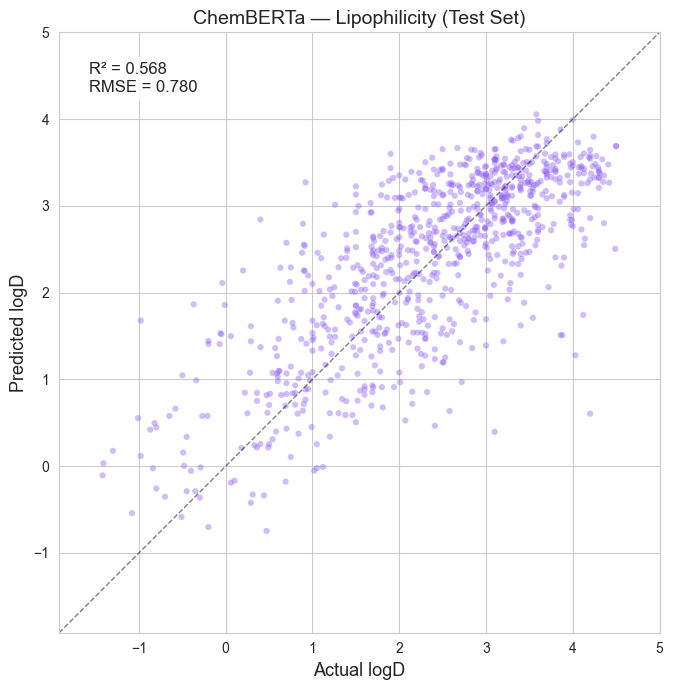

In [336]:
# Predicted vs actual scatter
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_true_test, y_pred_test, alpha=0.4, s=20, c='#8b5cf6', edgecolors='none')

lims = [min(y_true_test.min(), y_pred_test.min()) - 0.5,
        max(y_true_test.max(), y_pred_test.max()) + 0.5]
ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5)

ax.text(0.05, 0.95, f'R² = {test_r2:.3f}\nRMSE = {test_rmse:.3f}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_xlabel('Actual logD', fontsize=13)
ax.set_ylabel('Predicted logD', fontsize=13)
ax.set_title('ChemBERTa — Lipophilicity (Test Set)', fontsize=14)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('../assets/phase3_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Compare Against All Baselines

Enter your Phase 1 & 2 results below so you have a full comparison table.
Replace the placeholder numbers with your actual results.

In [388]:
# Replace these with your actual Phase 1 & 2 results
comparison = pd.DataFrame([
    # Phase 1
    {'Phase': 1, 'Model': 'Random Forest', 'Features': 'Morgan FP', 'Test RMSE': 0.9255, 'Test R²': 0.3920},
    # Phase 2 — add your best configurations
    {'Phase': 2, 'Model': 'Random Forest', 'Features': 'Combined', 'Test RMSE': 0.8077, 'Test R²': 0.5369},
    {'Phase': 2, 'Model': 'XGBoost', 'Features': 'Combined', 'Test RMSE': 0.7108, 'Test R²': 0.6413},
    # Phase 3
    {'Phase': 3, 'Model': 'ChemBERTa', 'Features': 'SMILES (learned)', 'Test RMSE': test_rmse, 'Test R²': test_r2},
])

print('\n=== Full Model Comparison ===')
print(comparison.to_string(index=False, float_format='%.4f'))


=== Full Model Comparison ===
 Phase         Model         Features  Test RMSE  Test R²
     1 Random Forest        Morgan FP     0.9255   0.3920
     2 Random Forest         Combined     0.8077   0.5369
     2       XGBoost         Combined     0.7108   0.6413
     3     ChemBERTa SMILES (learned)     0.7841   0.5636


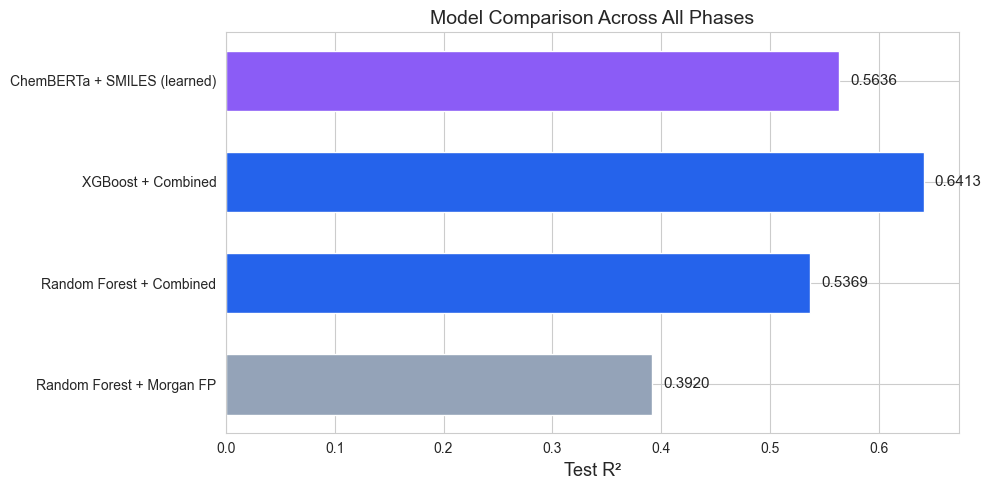

In [389]:
# Visual comparison
fig, ax = plt.subplots(figsize=(10, 5))

colors = {1: '#94a3b8', 2: '#2563eb', 3: '#8b5cf6'}
bars = ax.barh(
    range(len(comparison)),
    comparison['Test R²'],
    color=[colors[p] for p in comparison['Phase']],
    edgecolor='white',
    height=0.6,
)

ax.set_yticks(range(len(comparison)))
ax.set_yticklabels([f"{r['Model']} + {r['Features']}" for _, r in comparison.iterrows()])
ax.set_xlabel('Test R²', fontsize=13)
ax.set_title('Model Comparison Across All Phases', fontsize=14)

# Add value labels on bars
for bar, val in zip(bars, comparison['Test R²']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=11)

plt.tight_layout()
plt.savefig('../assets/phase3_full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Attention Visualization

One advantage of transformer models: we can look at the **attention weights**
to see which parts of the SMILES string the model focuses on when making predictions.
This gives us some interpretability.

In [390]:
def get_attention_weights(smiles, model, tokenizer, device):
    """Extract attention weights for a single molecule."""
    model.eval()
    encoding = tokenizer(
        smiles, return_tensors='pt', padding=True, truncation=True, max_length=128
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=True,
        )

    # Average attention across all heads in the last layer
    # Shape: (batch, heads, seq_len, seq_len) -> (seq_len,)
    last_layer_attn = outputs.attentions[-1].squeeze(0)  # (heads, seq, seq)
    avg_attn = last_layer_attn.mean(dim=0)  # (seq, seq)

    # Attention FROM the [CLS] token (row 0) TO all other tokens
    cls_attn = avg_attn[0].cpu().numpy()

    # Get tokens (excluding padding)
    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze().cpu())
    mask = attention_mask.squeeze().cpu().numpy()
    valid_len = int(mask.sum())

    tokens = tokens[:valid_len]
    cls_attn = cls_attn[:valid_len]

    # Normalize
    cls_attn = cls_attn / cls_attn.sum()

    return tokens, cls_attn


def plot_attention(smiles, model, tokenizer, device, prediction=None):
    """Visualize attention weights for a molecule."""
    tokens, attn = get_attention_weights(smiles, model, tokenizer, device)

    fig, ax = plt.subplots(figsize=(max(8, len(tokens) * 0.5), 3))

    # Color by attention weight
    colors = plt.cm.YlOrRd(attn / attn.max())

    bars = ax.bar(range(len(tokens)), attn, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=10, fontfamily='monospace')
    ax.set_ylabel('Attention Weight')

    title = f'CLS Attention — {smiles}'
    if prediction is not None:
        title += f' (predicted logD = {prediction:.2f})'
    ax.set_title(title, fontsize=12)

    plt.tight_layout()
    return fig


Aspirin: predicted logD = -2.249


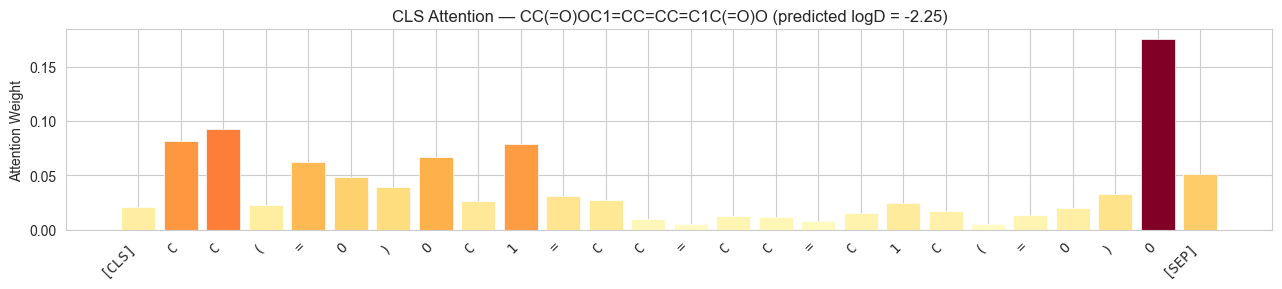


Caffeine: predicted logD = -1.834


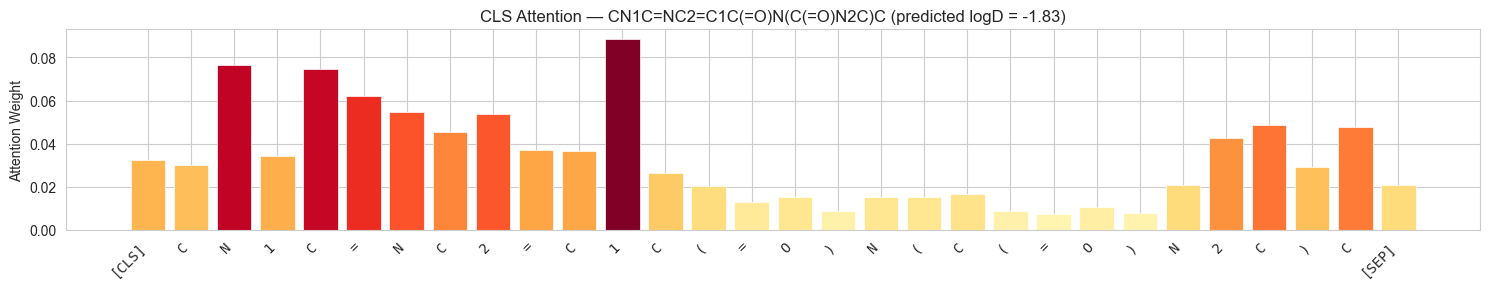


Ibuprofen: predicted logD = -0.923


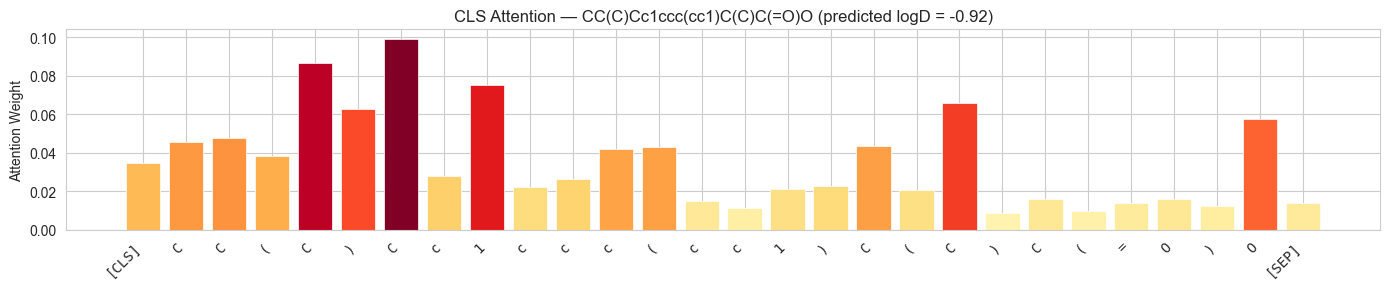


Testosterone: predicted logD = 0.896


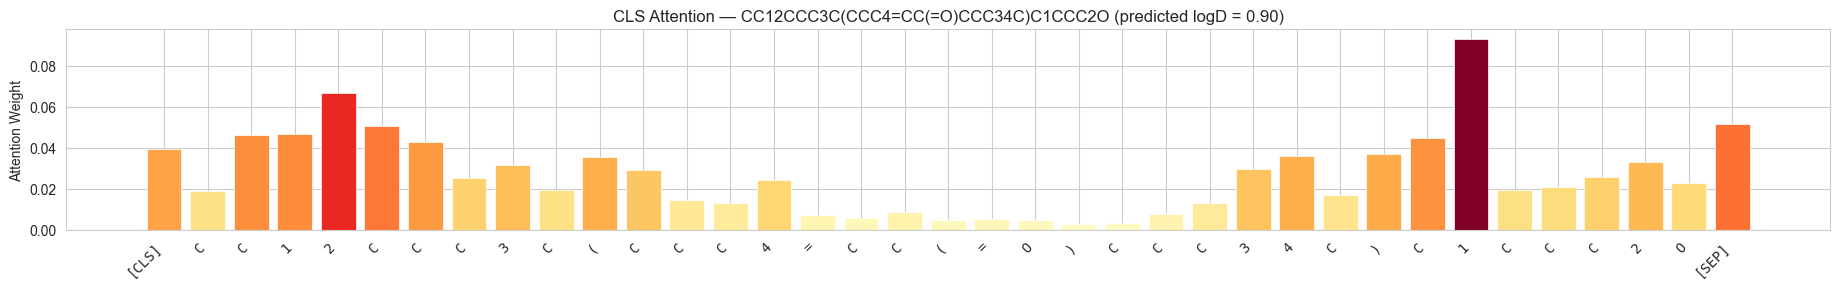

In [ ]:
# Visualize attention for a few well-known molecules
demo_molecules = [
    ('CC(=O)OC1=CC=CC=C1C(=O)O', 'Aspirin'),
    ('CN1C=NC2=C1C(=O)N(C(=O)N2C)C', 'Caffeine'),
    ('CC(C)Cc1ccc(cc1)C(C)C(=O)O', 'Ibuprofen'),
    ('CC12CCC3C(CCC4=CC(=O)CCC34C)C1CCC2O', 'Testosterone'),
]

for smiles, name in demo_molecules:
    # Get prediction
    encoding = tokenizer(smiles, return_tensors='pt', padding=True, truncation=True, max_length=128)
    with torch.no_grad():
        pred_scaled = model(
            encoding['input_ids'].to(device),
            encoding['attention_mask'].to(device),
        ).item()

    pred = y_scaler.inverse_transform([[pred_scaled]])[0][0]  # add this

    print(f'\n{name}: predicted logD = {pred:.3f}')
    fig = plot_attention(smiles, model, tokenizer, device, prediction=pred)
    fig.savefig(f'../assets/phase3_attention_{name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 11. Save the Model

In [393]:
import os
os.makedirs('../models', exist_ok=True)

# Save the full model state
torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'base_model_name': MODEL_NAME,
        'hidden_size': hidden_size,
        'dropout': DROPOUT,
        'max_length': MAX_LENGTH,
    },
    'test_metrics': {
        'rmse': test_rmse,
        'mae': test_mae,
        'r2': test_r2,
    },
    'y_scaler_mean': y_scaler.mean_[0],
    'y_scaler_scale': y_scaler.scale_[0],
}, '../models/chemberta_lipophilicity.pt')

print('Model saved to models/chemberta_lipophilicity.pt')

Model saved to models/chemberta_lipophilicity.pt


## 12. Summary

Fill in your observations after running:

In [394]:
print('='*60)
print('PHASE 3 SUMMARY')
print('='*60)

print(f'\nChemBERTa test performance:')
print(f'  RMSE: {test_rmse:.4f}')
print(f'  MAE:  {test_mae:.4f}')
print(f'  R²:   {test_r2:.4f}')

print('\n\nKey questions:')
print('  1. Did ChemBERTa beat the best classical baseline?')
print('     → [YOUR OBSERVATION]')
print('  2. How many epochs were needed before early stopping?')
print('     → [YOUR OBSERVATION]')
print('  3. Are there signs of overfitting in the training curves?')
print('     → [YOUR OBSERVATION]')
print('  4. What do the attention patterns reveal?')
print('     → [YOUR OBSERVATION]')

print('\n\nNext: Phase 4 — Build an interactive demo and polish the repo!')

PHASE 3 SUMMARY

ChemBERTa test performance:
  RMSE: 0.7841
  MAE:  0.5999
  R²:   0.5636


Key questions:
  1. Did ChemBERTa beat the best classical baseline?
     → [YOUR OBSERVATION]
  2. How many epochs were needed before early stopping?
     → [YOUR OBSERVATION]
  3. Are there signs of overfitting in the training curves?
     → [YOUR OBSERVATION]
  4. What do the attention patterns reveal?
     → [YOUR OBSERVATION]


Next: Phase 4 — Build an interactive demo and polish the repo!


## Things to Try

If you want to improve ChemBERTa's performance further:

- **Try ChemBERTa-v2**: `seyonec/ChemBERTa-zinc250k-v2` — trained on a different dataset
- **Freeze early layers**: Only train the last few transformer layers + head, which reduces overfitting on small datasets
- **Larger regression head**: Try adding another hidden layer or increasing the dimension
- **Learning rate sweep**: Try 1e-5, 2e-5, 5e-5 and compare validation curves
- **Multi-task learning**: Fine-tune on multiple ADME properties simultaneously
- **Data augmentation**: SMILES can represent the same molecule in multiple ways — enumerate variants